In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p src
!cp /content/drive/MyDrive/progetto-daml/src/preprocessing.py src/
!cp /content/drive/MyDrive/progetto-daml/src/plotting.py src/plotting.py

In [ ]:
# Import Required Libraries
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import sys
from sklearn.metrics import confusion_matrix
sys.path.append('/content/src')
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report


# Model Evaluation on PlantVillage Dataset

This notebook evaluates the trained model using the test set. It includes metrics, confusion matrix, ROC curves, and a classification report.

In [ ]:
# setup

# Choose number of samples per class:
#'max': # of samples in largest class
#'mean': mean # of samples
#'t': 1000 samples
#'min': # of samples in the smallest class

target_type = input("Choose the number of samples per class('max', 'mean', 't', 'min'): ").strip().lower()
if target_type not in ['max', 'mean', 't', 'min']:
    raise ValueError("Invalid choice! Please enter 'max', 'mean', 't', or 'min'.")

print(f"You chose: {target_type}")

if target_type == 'max':
  target = 4399

elif target_type == 'mean':
  target = 1143

elif target_type == 't':
  target = 200

elif target_type == 'min':
  target = 122
samplesize = str(target)

# Choose augmentation type:
#'comb': geometric and color augmentation
#'geo': geometric augmentation
#'color': color augmentation

augmentation_type = input("Choose augmentation type ('comb', 'geo', 'color', or 'sampl'): ").strip().lower()
if augmentation_type not in ['comb', 'geo', 'color', 'sampl']:
    raise ValueError("Invalid choice! Please enter 'none', 'geo', 'color', or 'sampl'.")

print(f"You chose: {augmentation_type}")


COMMON_FILENAME = augmentation_type+'_aug_'+samplesize

WEIGHTS_DIR = '/content/drive/MyDrive/progetto-daml/weights'  # Directory to save model weights
CONFUSION_DIR = '/content/drive/MyDrive/progetto-daml/conf-matrix'  # Directory to save confusion matrices
ROC_AUC_DIR = '/content/drive/MyDrive/progetto-daml/roc-curves'  # Directory to save ROC AUC plots
REPORTS_DIR = '/content/drive/MyDrive/progetto-daml/reports'  # Directory to save reports
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(CONFUSION_DIR, exist_ok=True)
os.makedirs(ROC_AUC_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
WEIGHTS_FILE = f'{WEIGHTS_DIR}/{COMMON_FILENAME}.h5'  # Path to save the best model weights
CONFUSION_FILE = f'{CONFUSION_DIR}/confusion_matrix_{COMMON_FILENAME}.png'  # Path to save confusion matrix
ROC_AUC_FILE = f'{ROC_AUC_DIR}/roc_curve_{COMMON_FILENAME}.png'  # Path to save ROC AUC plot
REPORT_TEXT_FILE = f'{REPORTS_DIR}/report_{COMMON_FILENAME}.txt'  # Path to save classification report
REPORT_SPC_TEXT_FILE = f'{REPORTS_DIR}/report_spc_{COMMON_FILENAME}.txt'  # Path to save classification report
REPORT_HEATMAP_FILE = f'{REPORTS_DIR}/report_heatmap_{COMMON_FILENAME}.png'  # Path to save heatmap of classification report
REPORT_SPC_HEATMAP_FILE = f'{REPORTS_DIR}/report_heatmap_spc_{COMMON_FILENAME}.png'  # Path to save heatmap of classification report

IMG_SIZE = (128, 128)  # Image size for resizing
BATCH_SIZE = 64  # Batch size dataset loading

# Copying the weights from the training of interest
weights_loc = '/content/drive/MyDrive/progetto-daml/weights/'+ augmentation_type +'_aug_'+ samplesize+'.h5'
print(weights_loc)
!cp "$weights_loc" /content/weights/

Choose the number of samples per class('max', 'mean', 't', 'min'): max
You chose: max
Choose augmentation type ('comb', 'geo', 'color', or 'sampl'): color
You chose: color
/content/drive/MyDrive/progetto-daml/weights/color_aug_4399.h5
cp: cannot create regular file '/content/weights/': Not a directory


In [ ]:
# Seed setting for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

In [ ]:
from preprocessing import preprocess

model = keras.models.load_model(WEIGHTS_FILE, compile=False)

ds_test, ds_info = tfds.load(
    'plant_village',
    split='train[95%:]',
    shuffle_files=False,
    as_supervised=True,  # returns (image, label) pairs
    with_info=True
)

test_ds = ds_test.map(lambda image, label: preprocess(image, label, ds_info, IMG_SIZE)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
class_names = ds_info.features['label'].names
print(f"Number of test images: {ds_info.splits['train[95%:]'].num_examples}")


Number of test images: 2715


In [ ]:
# Generate Predictions on Test Set
y_true = []
y_pred = []
y_score = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.append(preds)
y_score = np.concatenate(y_score)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Calculate evaluation metrics (Accuracy, Precision, Recall, F1)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-score: {f1:.6f}")


Accuracy: 0.508287
Precision: 0.497572
Recall: 0.508287
F1-score: 0.499829


<Figure size 640x480 with 0 Axes>

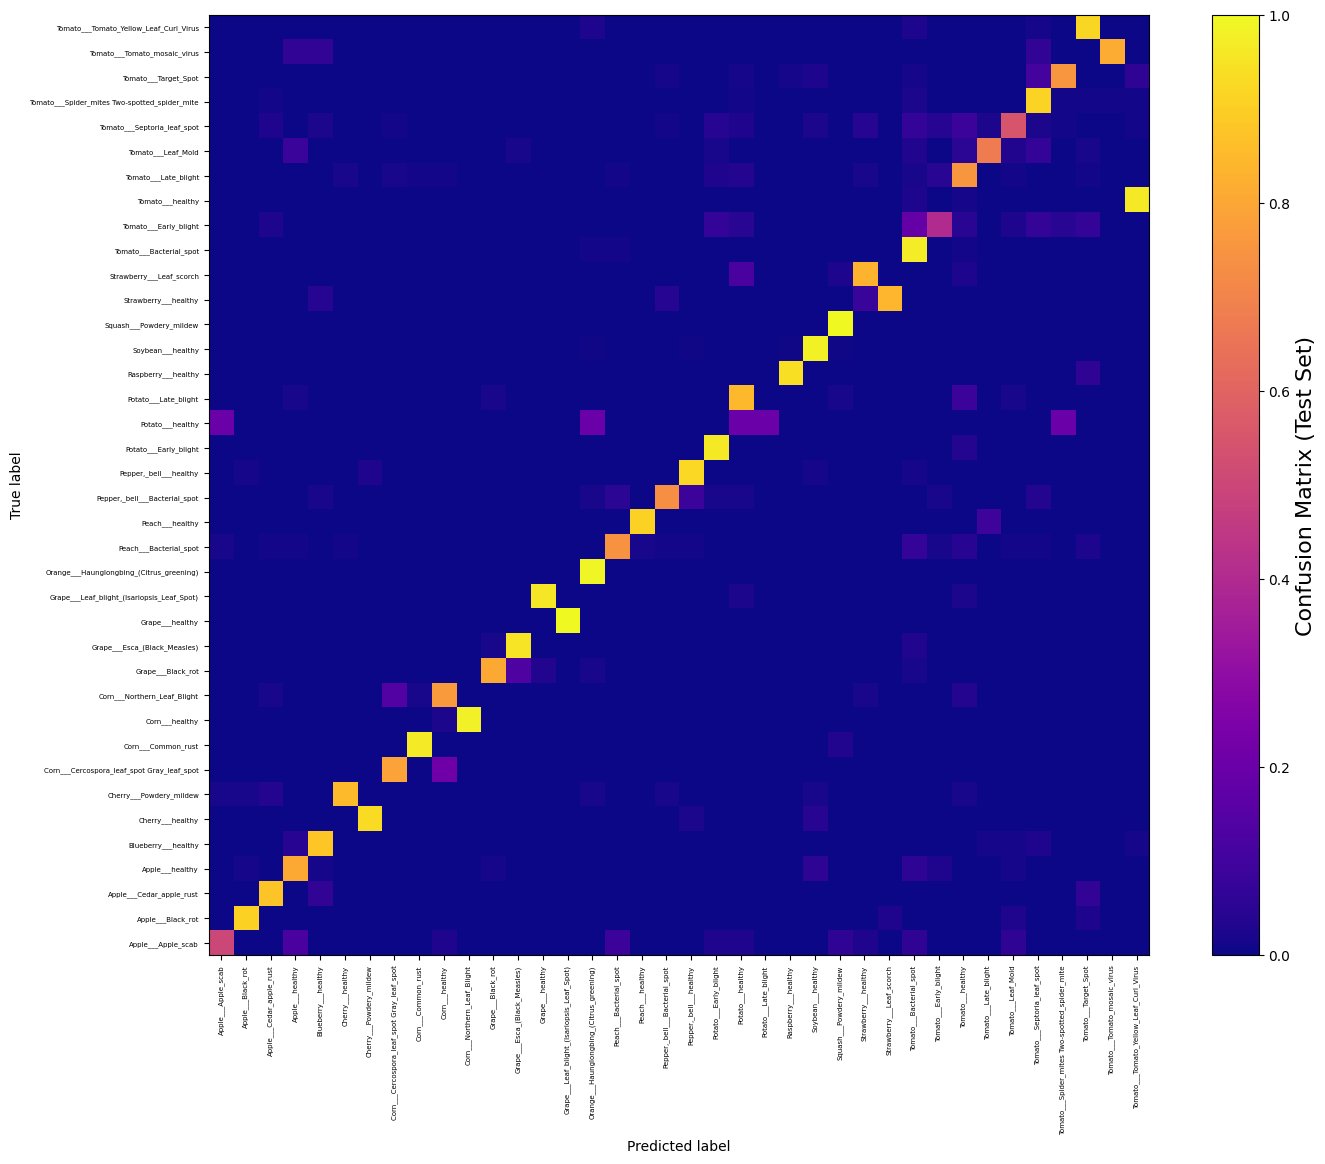

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from plotting import plot_confusion_matrix4

plt.figure()  # Set a larger figure size for better readability
plot_confusion_matrix4(
    np.array(y_true),
    np.array(y_pred),
    classes=class_names,
    normalize=True,
    title="Confusion Matrix (Test Set)",
    cmap="plasma"
)
plt.tight_layout()  # Ensure labels and ticks are not cut off
plt.savefig(CONFUSION_FILE, dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_potato_confusion_matrix(y_true, y_pred, class_names, normalize=False, title=None, cmap=plt.cm.Blues):
    """
    Plots a confusion matrix focused on the potato-related classes.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = "Normalized confusion matrix (Potato classes)"
        else:
            title = "Confusion matrix (Potato classes)"

    # 1. Identify Potato classes
    potato_classes = [i for i, name in enumerate(class_names) if 'Potato' in name]
    potato_names = [class_names[i] for i in potato_classes]

    # 2. Filter y_true and y_pred for the potato-related classes
    y_true_potato = []
    y_pred_potato = []

    for t, p in zip(y_true, y_pred):
        if t in potato_classes:
            y_true_potato.append(t)
            y_pred_potato.append(p)

    # 3. Compute the confusion matrix for the potato classes
    cm = confusion_matrix(y_true_potato, y_pred_potato, labels=potato_classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # 4. Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))  # Adjust figure size for better readability
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap, origin="lower")  # Ensure proper colormap is applied
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.set_label(title, fontsize=16)

    # 5. Set up tick marks and labels
    tick_marks = np.arange(len(potato_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)

    # Set potato class names for labels
    plt.xticks(tick_marks, potato_names, rotation=45, fontsize=12)
    plt.yticks(tick_marks, potato_names, fontsize=12)

    # Adjust layout to avoid overlap
    plt.tight_layout(pad=2.0)  # Increase padding to avoid overlap
    plt.show()


<Figure size 640x480 with 0 Axes>

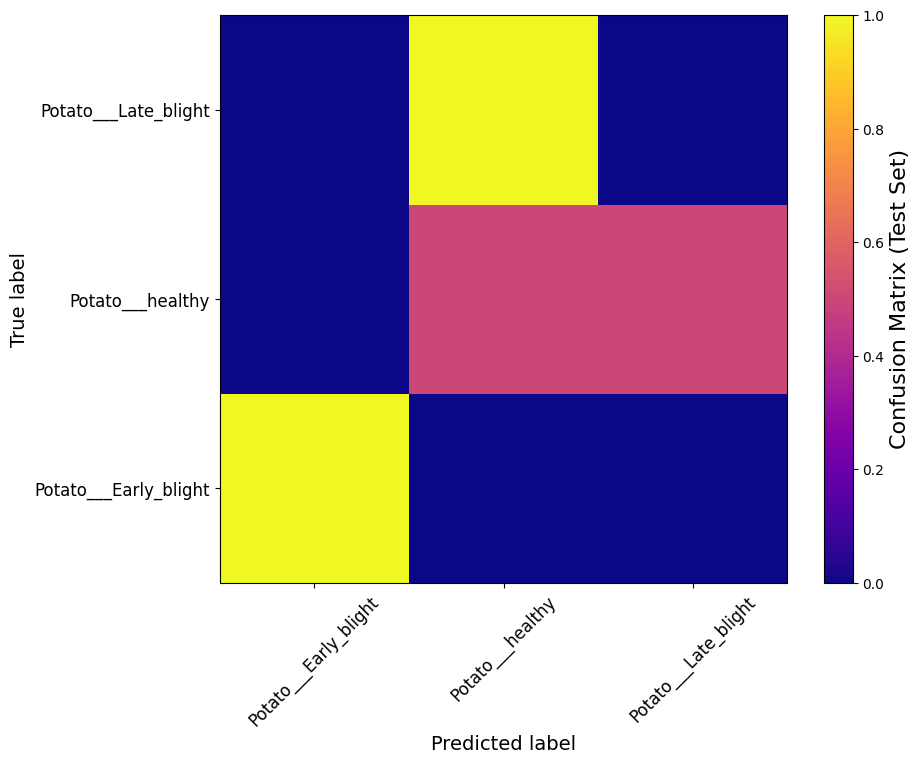

<Figure size 640x480 with 0 Axes>

In [ ]:
#import matplotlib.pyplot as plt
#from plotting import plot_potato_confusion_matrix

plt.figure()  # Set a larger figure size for better readability
plot_potato_confusion_matrix(
    np.array(y_true),
    np.array(y_pred),
    class_names,
    normalize=True,
    title="Confusion Matrix (Test Set)",
    cmap="plasma"
)
plt.tight_layout()  # Ensure labels and ticks are not cut off
plt.savefig(CONFUSION_FILE, dpi=400, bbox_inches='tight')
plt.show()

## Species specific confusion matrix

In [ ]:
# Definition of the map to switch to the species analysis

species_map = {
    "Apple___Apple_scab": "Apple",
    "Apple___Black_rot": "Apple",
    "Apple___Cedar_apple_rust": "Apple",
    "Apple___healthy": "Apple",
    "Blueberry___healthy": "Blueberry",
    "Cherry___healthy": "Cherry",
    "Cherry___Powdery_mildew": "Cherry",
    "Corn___Cercospora_leaf_spot Gray_leaf_spot": "Corn",
    "Corn___Common_rust": "Corn",
    "Corn___healthy": "Corn",
    "Corn___Northern_Leaf_Blight": "Corn",
    "Grape___Black_rot": "Grape",
    "Grape___Esca_(Black_Measles)": "Grape",
    "Grape___healthy": "Grape",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Grape",
    "Orange___Haunglongbing_(Citrus_greening)": "Orange",
    "Peach___Bacterial_spot": "Peach",
    "Peach___healthy": "Peach",
    "Pepper,_bell___Bacterial_spot": "Pepper",
    "Pepper,_bell___healthy": "Pepper",
    "Potato___Early_blight": "Potato",
    "Potato___healthy": "Potato",
    "Potato___Late_blight": "Potato",
    "Raspberry___healthy": "Raspberry",
    "Soybean___healthy": "Soybean",
    "Squash___Powdery_mildew": "Squash",
    "Strawberry___healthy": "Strawberry",
    "Strawberry___Leaf_scorch": "Strawberry",
    "Tomato___Bacterial_spot": "Tomato",
    "Tomato___Early_blight": "Tomato",
    "Tomato___healthy": "Tomato",
    "Tomato___Late_blight": "Tomato",
    "Tomato___Leaf_Mold": "Tomato",
    "Tomato___Septoria_leaf_spot": "Tomato",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Tomato",
    "Tomato___Target_Spot": "Tomato",
    "Tomato___Tomato_mosaic_virus": "Tomato",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Tomato"
}


In [ ]:
#4
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def plot_species_confusion_matrix(y_true, y_pred, class_names, species_map,
                                  normalize=True, title=None, cmap=plt.cm.plasma):

    # Map indices to classes names
    idx_to_class = {i: name for i, name in enumerate(class_names)}
    species_true = [species_map[idx_to_class[t]] for t in y_true]
    species_pred = [species_map[idx_to_class[p]] for p in y_pred]

    # Species labs. frm left to rt
    species_labels = sorted(set(species_map.values()))

    #Confusion matrix
    cm_species = confusion_matrix(species_true, species_pred, labels=species_labels)
    if normalize:
        cm_species = cm_species.astype('float') / cm_species.sum(axis=1, keepdims=True)

    # This should flip vertically the labs
    cm_species_display = np.flipud(cm_species)


    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_species_display, interpolation='nearest', cmap=cmap, aspect='auto')
    ax.figure.colorbar(im, ax=ax).set_label(title or "Species-level Confusion Matrix")

    tick_marks = np.arange(len(species_labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(species_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(species_labels[::-1], fontsize=9)
    ax.set_xlabel('Predicted Species')
    ax.set_ylabel('True Species')

    plt.tight_layout()
    plt.show()

    print("Species-level classification report:\n")
    print(classification_report(species_true, species_pred, target_names=species_labels))

    return cm_species

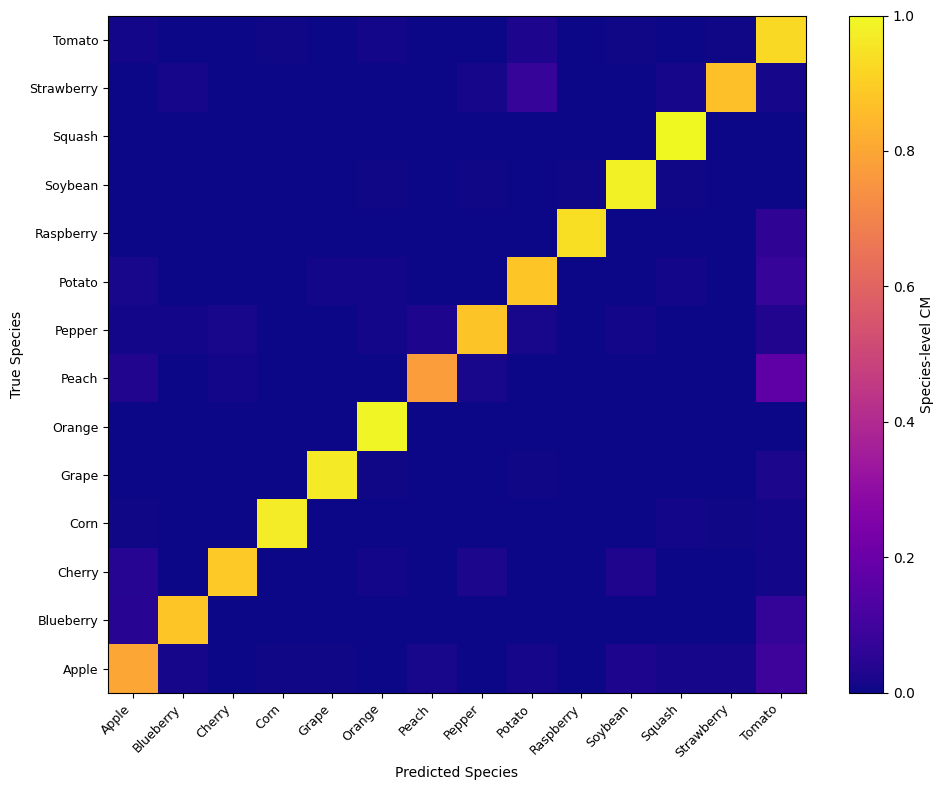

Species-level classification report:

              precision    recall  f1-score   support

       Apple       0.82      0.80      0.81       155
   Blueberry       0.90      0.88      0.89        68
      Cherry       0.95      0.89      0.92        98
        Corn       0.97      0.97      0.97       193
       Grape       0.98      0.97      0.98       189
      Orange       0.95      0.99      0.97       276
       Peach       0.91      0.77      0.84       124
      Pepper       0.92      0.88      0.90       121
      Potato       0.76      0.88      0.82       118
   Raspberry       0.89      0.94      0.91        17
     Soybean       0.95      0.98      0.97       253
      Squash       0.93      1.00      0.96        93
  Strawberry       0.87      0.87      0.87        67
      Tomato       0.93      0.93      0.93       943

    accuracy                           0.92      2715
   macro avg       0.91      0.91      0.91      2715
weighted avg       0.93      0.92      0.9

In [ ]:
cm_species = plot_species_confusion_matrix(y_true, y_pred, class_names, species_map, normalize=True, title="Species-level CM")

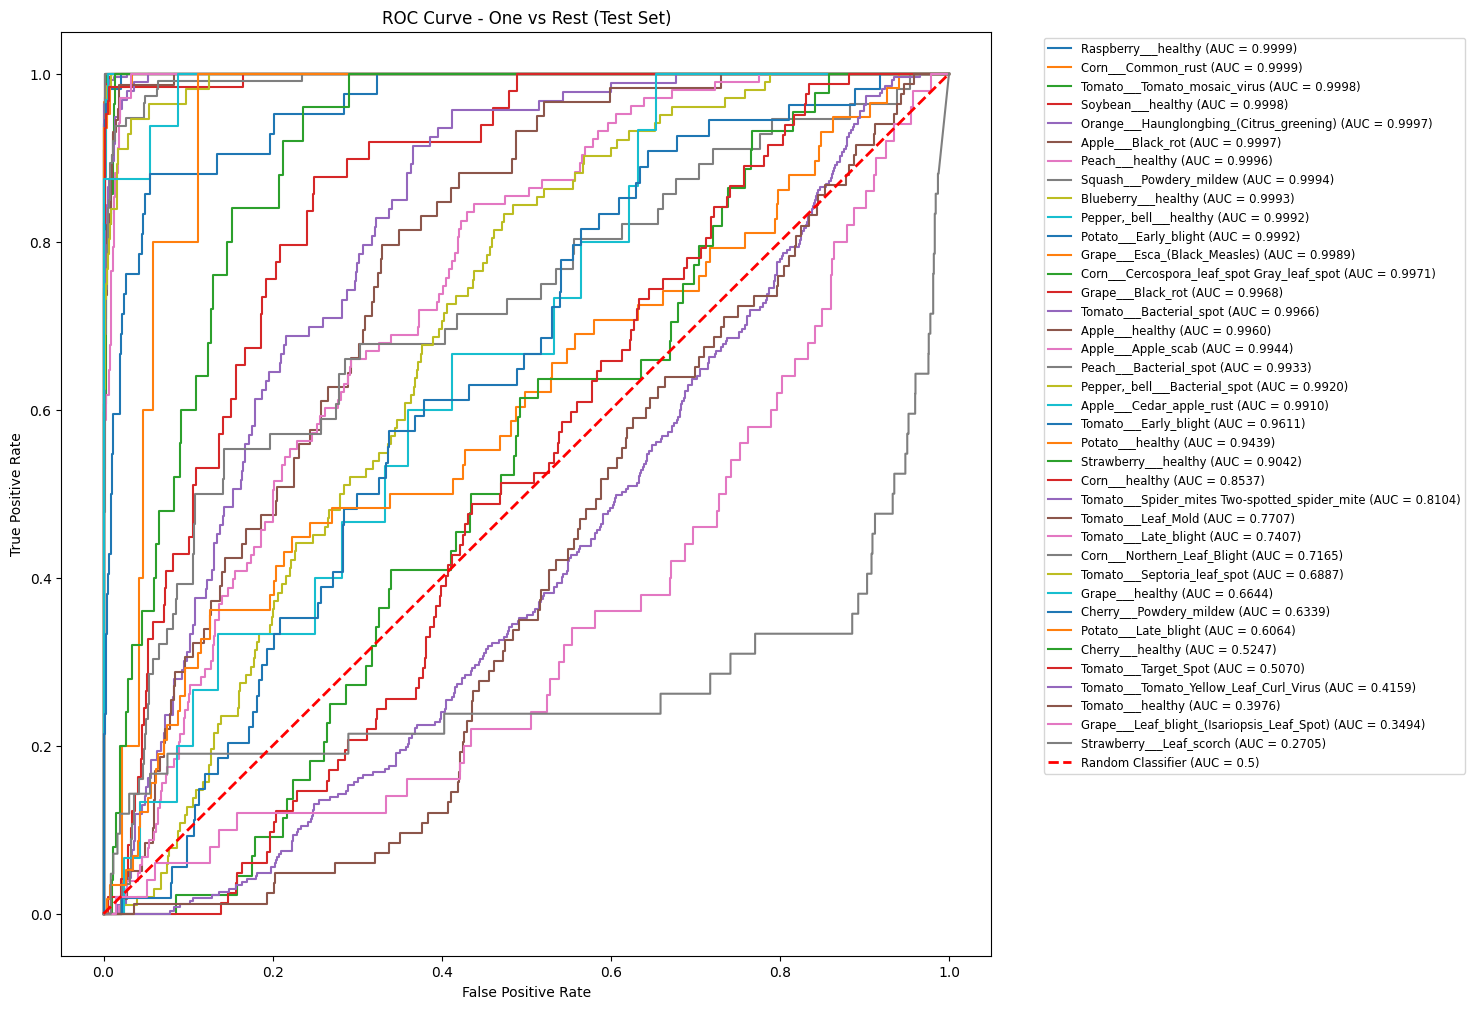

In [ ]:
# Plot ROC curves for Each Class (not species)
n_classes = y_score.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(np.eye(n_classes)[y_true][:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(np.eye(n_classes)[y_true][:, i], y_score[:, i])
plt.figure(figsize=(12, 12))
auc_and_idx = sorted([(roc_auc[i], i) for i in range(n_classes)], reverse=True)
for auc, i in auc_and_idx:
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - One vs Rest (Test Set)')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='best')
plt.savefig(ROC_AUC_FILE, dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
# Display classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save the classification report to a text file
with open(REPORT_TEXT_FILE, 'w') as f:
    f.write(report)

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.81      0.50      0.62        34
                            Apple___Black_rot       0.91      0.91      0.91        33
                     Apple___Cedar_apple_rust       0.58      0.88      0.70        16
                              Apple___healthy       0.79      0.81      0.80        72
                          Blueberry___healthy       0.90      0.88      0.89        68
                             Cherry___healthy       0.00      0.00      0.00        44
                      Cherry___Powdery_mildew       0.00      0.00      0.00        54
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.67      0.79      0.72        28
                           Corn___Common_rust       0.97      0.97      0.97        60
                               Corn___healthy       0.02      0.02      0.02        49
                  Corn___Northern_Leaf_Bli

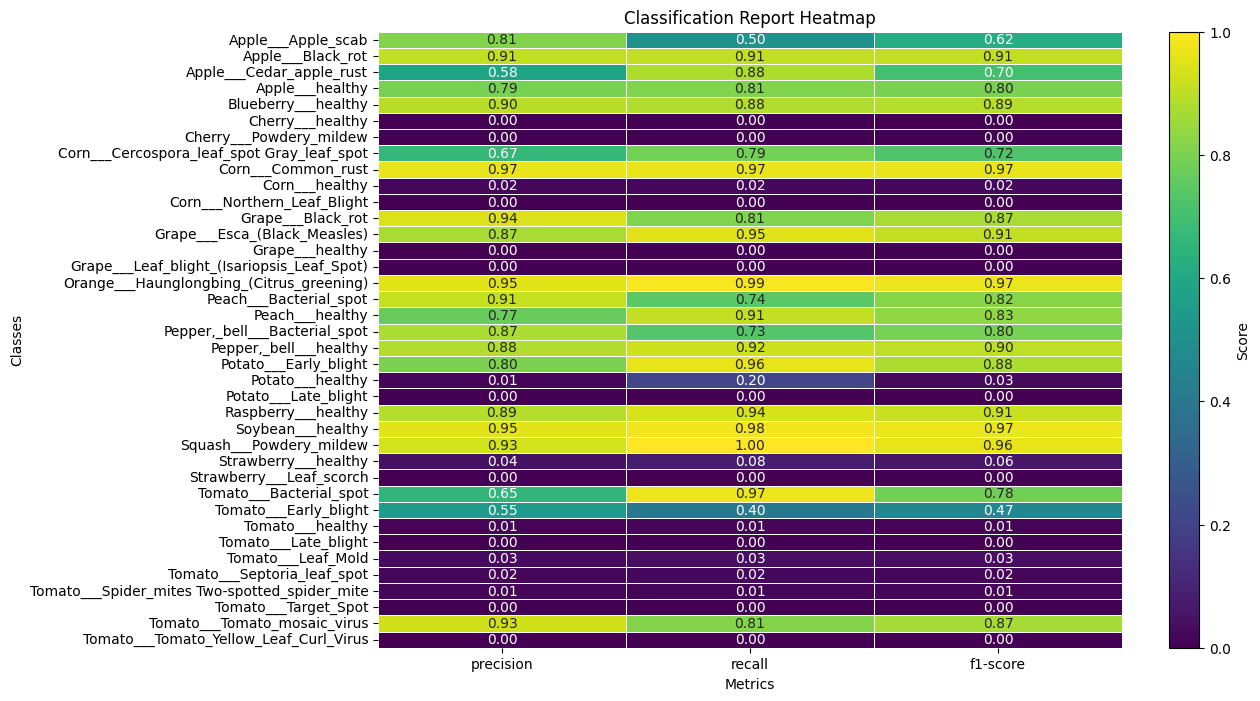

In [ ]:
# heatmap of the classification report
import seaborn as sns
import pandas as pd
report_df = pd.DataFrame.from_dict(
    classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
).T

fig, ax = plt.subplots(figsize=(12, 8))
hm = sns.heatmap(
    report_df.iloc[:-3, :-1],
    annot=True,
    fmt='.2f',
    cmap='viridis',
    cbar=False,
    linewidths=0.5,
    ax=ax
)
cbar = fig.colorbar(hm.collections[0], ax=ax)
cbar.set_label('Score')

plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.savefig(REPORT_HEATMAP_FILE, dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

idx_to_class = {i: name for i, name in enumerate(class_names)}   #just like int he definitionof the conf. mat. for the potato classes
species_true = [species_map[idx_to_class[t]] for t in y_true]
species_pred = [species_map[idx_to_class[p]] for p in y_pred]
species_labels = sorted(set(species_map.values()))

report_species = classification_report(species_true, species_pred, target_names=species_labels)
print(report_species)
with open(REPORT_SPC_TEXT_FILE, 'w') as f:
    f.write(report_species)

              precision    recall  f1-score   support

       Apple       0.82      0.80      0.81       155
   Blueberry       0.90      0.88      0.89        68
      Cherry       0.95      0.89      0.92        98
        Corn       0.97      0.97      0.97       193
       Grape       0.98      0.97      0.98       189
      Orange       0.95      0.99      0.97       276
       Peach       0.91      0.77      0.84       124
      Pepper       0.92      0.88      0.90       121
      Potato       0.76      0.88      0.82       118
   Raspberry       0.89      0.94      0.91        17
     Soybean       0.95      0.98      0.97       253
      Squash       0.93      1.00      0.96        93
  Strawberry       0.87      0.87      0.87        67
      Tomato       0.93      0.93      0.93       943

    accuracy                           0.92      2715
   macro avg       0.91      0.91      0.91      2715
weighted avg       0.93      0.92      0.92      2715



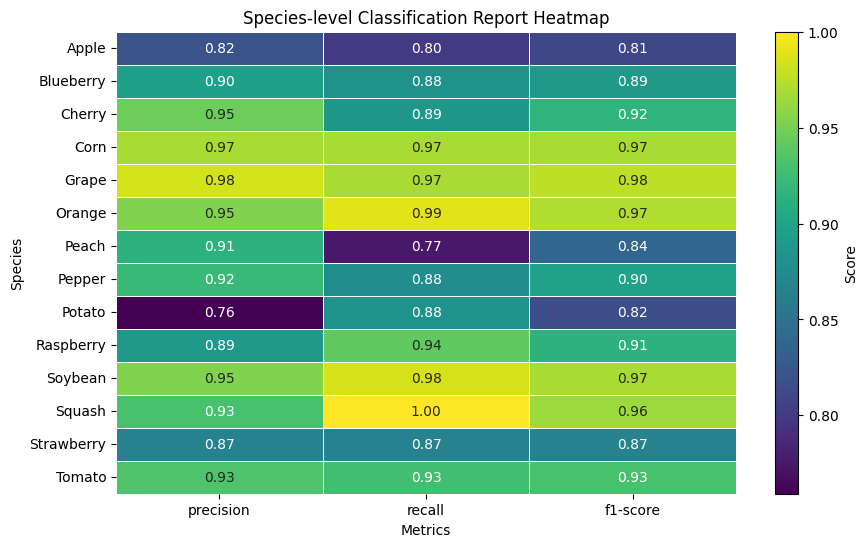

In [ ]:
idx_to_class = {i: name for i, name in enumerate(class_names)}
species_true = [species_map[idx_to_class[t]] for t in y_true]
species_pred = [species_map[idx_to_class[p]] for p in y_pred]
species_labels = sorted(set(species_map.values()))

report_species_df = pd.DataFrame.from_dict(
    classification_report(
        species_true, species_pred, target_names=species_labels, output_dict=True
    )
).T

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
hm = sns.heatmap(
    report_species_df.iloc[:-3, :-1],
    annot=True,
    fmt='.2f',
    cmap='viridis',
    cbar=False,
    linewidths=0.5,
    ax=ax
)

cbar = fig.colorbar(hm.collections[0], ax=ax)
cbar.set_label('Score')

plt.title('Species-level Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Species')
plt.savefig(REPORT_SPC_HEATMAP_FILE, dpi=400, bbox_inches='tight')
plt.show()